# Assignment 3: OpenAlex api

**Sally Choi**  

**DATASCI 530**

## Introduction
OpenAlex is an online catalog of research publications from around the world. It provides information about publications, including their titles, publication years, authors, institutional affiliations, and citation counts. This report uses the OpenAlex's API, which allows Python to request selected information directly from the catalog. The first part of the report examines how many works have the phrase artificial intelligence in their titles. It then focuses on works published since 2000 and compares the countries connected to the authors' institutional affiliations.

#### **Key Findings:**
OpenAlex identified 330,000+ works with “artificial intelligence” in their titles. Since 2000, the United States, China, and India have produced the largest numbers of publications based on authors’ institutional affiliations. Publication volume increased especially rapidly after 2020, with strong recent growth in titles containing “LLM.” Computer Science and Medicine contain nearly equal shares of classified AI publications, showing that artificial intelligence has become important well beyond traditional computing research.
*Note:The 2026 counts represent an incomplete publication year when this report was produced, so they should not be treated as final totals.

In [7]:
# Import libraries

import requests
import json
import pandas as pd

## 1. How many works have “artificial intelligence” in their titles
"Work" means a scholarly research item (e.g., a journal article, book, book chapter, conference paper, research publication, etc.) 

**Process**
- Ask the OpenAlex research database to find works whose titles contain the phrase "artificial intelligence."
- OpenAlex returns the results in JSON format, which organizes information using labels and values. The response has a summary section called meta, and inside that section, count gives the total number of matching publications.

In [5]:
# define openalex address (to search publication titles)
url_question1_api = 'https://api.openalex.org/works?filter=title.search:"artificial intelligence"'

# request info and convert the JSON response to a python object
ai_search = requests.get(url_question1_api).json()

# extract total number of matching works from the search results
count_ai_search = ai_search["meta"]["count"]

print("Works with 'artificial intelligence' in the title:", count_ai_search)

Works with 'artificial intelligence' in the title: 330744


## 2. Publications since 2000 by grouped by authors' countries

#### Question: Restrict the analysis to works published since 2000 and group by the country of the authors’ affiliations. Produce a table that sorts the countries by the number of publications about artificial intelligence.

**Process**
- Use the same title search, but add a year restriction. (publication_year:>1999 includes works published in 2000 or later)
- Ask OpenAlex to group the matching works by the countries connected to their authors' affiliations. OpenAlex returns each country's name and publication count in the group_by section.
- Convert the grouped JSON information into a pandas table, give the columns clearer names, and sort the countries from the largest publication count to the smallest.
- A publication can include authors affiliated with institutions in more than one country. In that situation, the publication appears in each represented country's count, so, adding all country counts can produce a total larger than the number of individual publications. 

In [66]:
# search titles, keep publications since 2000, and group by country
url_question2_api = \
    ('https://api.openalex.org/works?'
     'filter=title.search:"artificial intelligence",publication_year:>1999'
     '&group_by=authorships.countries&per-page=200')

# request the grouped information and convert the JSON response
country_search = requests.get(url_question2_api).json()

In [65]:
# convert the country groups into a pandas table
country_table = pd.DataFrame(country_search["group_by"])

# keep the country name and count but w/ readable column names
country_table = (country_table
    [["key_display_name", "count"]].rename(columns = {
        "key_display_name": "Country",
        "count": "Number of publications"})
        .sort_values(by = "Number of publications", ascending = False))

# format the top 20 countries as table
country_display = (country_table.head(20)
    .style
    .format({"Number of publications": "{:,.0f}"})
    .hide(axis = "index")
    .set_caption("Table 1. Top 20 countries with the most artificial-intelligence publications since 2000"))

display(country_display)

Country,Number of publications
United States,"37,241"
China,"30,124"
India,"25,011"
United Kingdom,"12,734"
Indonesia,"9,434"
Italy,"7,470"
Germany,"6,925"
Turkey,"6,718"
Russia,"5,968"
Canada,"5,915"


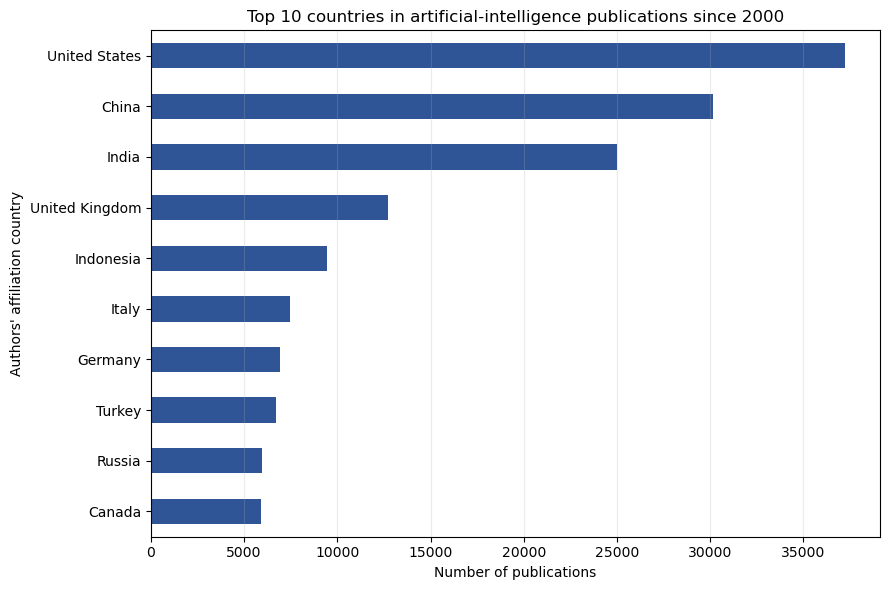

In [64]:
# select and order the top 10 countries for a horizontal bar chart
country_plot = (country_table.head(10)
    .sort_values(by = "Number of publications", ascending = True))

country_plot.plot(
    x = "Country",
    y = "Number of publications",
    kind = "barh",
    figsize = (9, 6),
    color = "#2F5597",
    legend = False)

plt.title("Top 10 countries in artificial-intelligence publications since 2000")
plt.xlabel("Number of publications")
plt.ylabel("Authors' affiliation country")
plt.grid(axis = "x", alpha = 0.25)
plt.tight_layout()
plt.show()

In [68]:
# check the size and completeness of the country results
print("'AI' works published since 2000:", country_search["meta"]["count"])
print("Country groups:", len(country_table))
# print("Missing values in the country table:")
# print(country_table.isna().sum())

'AI' works published since 2000: 324957
Country groups: 200


### Findings
- The United States had the largest affiliation-based publication count since 2000, with 37,241 works.
- China ranked second with 30,124 publications, followed by India with 25,011.
- The United Kingdom ranked fourth with 12,734 publications. Its count was approximately half of India’s total, showing a noticeable difference between the three leading countries and the remaining countries.
- A publication can be counted for multiple countries when its authors have affiliations in different countries. The country totals therefore should not be added together to calculate the number of unique publications.



## 3. Ten most highly cited papers since 2000

#### Question: What are the titles of the 10 most highly cited papers on artificial intelligence since 2000? How many citations do they have? Who are the authors, and what institutions are they affiliated with?

**Process**
- Use the same title and publication-year restrictions as Question 2. But also ask to sort the matching works by citation count from highest to lowest and return the first 10 records.
- Ask OpenAlex to sort the matching works by citation count from highest to lowest and return the first 10 records.
- Extract each publication’s title, publication year, and citation count from the JSON response.
- Use the nested authorship information to identify the authors and their institutional affiliations.
- Display the first three authors and their affiliations for each publication. When a paper has more than three authors, report the number of additional authors using a label such as (+9 authors) for readability.

In [74]:
# search titles, keep publications since 2000, and sort by citations
url_question3 = \
    ('https://api.openalex.org/works?'
     'filter=title.search:"artificial intelligence",publication_year:>1999'
     '&sort=cited_by_count:desc&per-page=10')

# request the information and extract the list of 10 publications
citation_results = requests.get(url_question3).json()
top_ten_results = citation_results["results"]

In [75]:
# create one row for each publication
top_ten_data = []

for i in range(len(top_ten_results)):
    publication = top_ten_results[i]

    top_ten_data.append({
        "Rank": i + 1,
        "Title": publication["title"],
        "Year": publication["publication_year"],
        "Citations": publication["cited_by_count"]})

# convert the publication information into a table
top_ten_papers = pd.DataFrame(top_ten_data)

In [83]:
# create a list for the author information
author_information_list = []

for publication in top_ten_results:
    author_information = ""

    # count all authors, but show no more than three
    number_authors = len(publication["authorships"])
    number_authors_to_show = number_authors

    if number_authors > 3:
        number_authors_to_show = 3

    # extract the first three authors
    for j in range(number_authors_to_show):
        authorship = publication["authorships"][j]
        author_name = authorship["author"]["display_name"]
        institution_information = ""

        # collect the institutions listed for this author
        for institution in authorship["institutions"]:
            if institution_information != "":
                institution_information = institution_information + "; "

            institution_information = (institution_information + institution["display_name"])

        if institution_information == "":
            institution_information = "Institution not listed"

        if author_information != "":
            author_information = author_information+", "

        author_information = (author_information+author_name+ " ("+ institution_information+ ")")

    # count the authors who are not displayed
    additional_authors = number_authors - number_authors_to_show

    if additional_authors == 1:
        author_information = author_information+" (+1 author)"
    elif additional_authors > 1:
        author_information = (author_information+" (+"+ str(additional_authors)+ " authors)")

    author_information_list.append(author_information)

In [82]:
# add the author and affiliation information to the publication table
top_ten_papers["Authors and affiliations"] = author_information_list

# quality checks
# print("Number of publications:", len(top_ten_papers))
# print("Number of author descriptions:", len(author_information_list))
# print("Missing values:")
# print(top_ten_papers.isna().sum())
print("10 publications were selected with 10 author descriptions, and there were no missing values in any column")

10 publications were selected with 10 author descriptions, and there were no missing values in any column


In [79]:
# format the table so full titles and author information wrap in the HTML report 
# (got help from AI to make table presentable)
question3_table = (top_ten_papers
    .style
    .format({"Citations": "{:,.0f}"})
    .hide(axis = "index")
    .set_caption("Table 2. Ten most highly cited papers on artificial intelligence since 2000")
    .set_properties(
        subset = ["Title"],
        **{"text-align": "left", "white-space": "normal", "min-width": "280px"})
    .set_properties(
        subset = ["Authors and affiliations"],
        **{"text-align": "left", "white-space": "normal", "min-width": "420px"})
    .set_properties(
        subset = ["Rank", "Year", "Citations"],
        **{"text-align": "center"}))

display(question3_table)

Rank,Title,Year,Citations,Authors and affiliations
1,High-performance medicine: the convergence of human and artificial intelligence,2018,"10,279",Eric J. Topol (Scripps Research Institute)
2,"Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI",2019,"10,137","Alejandro Barredo Arrieta (Tecnalia), Natalia Díaz-Rodríguez (Institut national de recherche en sciences et technologies du numérique; École Nationale Supérieure de Techniques Avancées; École Nationale Supérieure de Techniques Avancées Paris; Unité d'Informatique et d'Ingénierie des Systèmes), Javier Del Ser (Tecnalia) (+9 authors)"
3,Systematic review of research on artificial intelligence applications in higher education – where are the educators?,2019,"6,847","Olaf Zawacki‐Richter (Carl von Ossietzky Universität Oldenburg), Victoria I. Marín (Carl von Ossietzky Universität Oldenburg), Melissa Bond (Carl von Ossietzky Universität Oldenburg) (+1 author)"
4,Peeking Inside the Black-Box: A Survey on Explainable Artificial Intelligence (XAI),2018,"6,290","Amina Adadi (Sidi Mohamed Ben Abdellah University), Mohammed Berrada (Sidi Mohamed Ben Abdellah University)"
5,Proceedings of the 19th International Joint Conference on Artificial Intelligence,2005,"5,781","Josep M. Pujol (Institution not listed), Jordi Delgado (Institution not listed), Ramón Sangüesa (Institution not listed) (+1 author)"
6,Explanation in artificial intelligence: Insights from the social sciences,2018,"5,266",Tim Miller (The University of Melbourne)
7,"Artificial intelligence in healthcare: past, present and future",2017,"4,901","Fei Jiang (University of Hong Kong), Yong Jiang (Capital Medical University; Beijing Tian Tan Hospital), Hui Zhi (University of Hong Kong) (+9 authors)"
8,"Artificial Intelligence (AI): Multidisciplinary perspectives on emerging challenges, opportunities, and agenda for research, practice and policy",2019,"4,526","Yogesh Kumar Dwivedi (Prin. L. N. Welingkar Institute of Management Development and Research; Swansea University), Laurie Hughes (Swansea University), Elvira Ismagilova (University of Bradford) (+32 authors)"
9,"BNAI, NO-TOKEN, and MIND-UNITY: Pillars of a Systemic Revolution in Artificial Intelligence",2022,"4,271","Wei, Jason (Google (United States)), Wang, Xuezhi (Google (United States)), Dale Schuurmans (Google (United States)) (+6 authors)"
10,Artificial Intelligence in Education: A Review,2020,"3,983","Lijia Chen (Yango University), Pingping Chen (Fuzhou University), Zhijian Lin (Fuzhou University)"


### Findings
- High-performance medicine: the convergence of human and artificial intelligence was the most highly cited paper in the results, with 10,279 citations.
- Explainable Artificial Intelligence (XAI): Concepts, taxonomies, opportunities and challenges toward responsible AI ranked second with 10,137 citations.
- The ten leading papers had between 3,983 and 10,279 citations, demonstrating that each has received substantial academic attention.
- Several highly cited papers focused on healthcare, explainable AI, education, and the social implications of artificial intelligence. This suggests that influential AI research extends beyond the technical development of computer systems.

## 4. Changes in publications by year since 2000

#### Question: How has the number of publications with the phrase "artificial intelligence" changed year-to-year since 2000? How does this compare to the use of the terms "LLM" and "GPT"? Repeat the year-to-year analysis for another keyword of your choice. Plot your results in a graph.

**Process**

Additional keyword: Machine learning --> 
I chose machine learning as the additional phrase since it is an area of research that is closely related and was established before the recent increase in interest in generative AI.

- Search publication titles for four terms: artificial intelligence, LLM, GPT, and machine learning
- Restrict search to publication years from 2000 through 2026. Ask OpenAlex to group the matching works by publication year so that the analysis uses annual totals rather than downloading every individual publication.
- Use a loop so that the same steps are applied consistently to all four key word searches and convert each JSON result into a pandas table and merge the annual counts using the year.
- Replace the missing value with zero (if there are no record for a keyword in a particular year). 

In [3]:
# define the key words
# terms used in the OpenAlex title searches
keyword_searches = ["artificial intelligence", "LLM", "GPT", "machine learning"]

# change labels used in the table and graph to make it readable
keyword_labels = ["Artificial intelligence", "LLM", "GPT", "Machine learning"]

In [9]:
# begin with one row for every year within the period
yearly_publications = pd.DataFrame({
    "Year": range(2000, 2027)}) 

# repeat the same OpenAlex request for each title search
for i in range(len(keyword_searches)):
    url_question4 = (
        'https://api.openalex.org/works?'
        'filter=title.search:"' + keyword_searches[i]
        + '",publication_year:2000-2026'
        + '&group_by=publication_year&per-page=200')

    yearly_search = requests.get(url_question4).json()

    # convert the grouped JSON results into table
    keyword_yearly = pd.DataFrame(yearly_search["group_by"])
    keyword_yearly = (keyword_yearly
        [["key", "count"]]
        .rename(columns = {
            "key": "Year",
            "count": keyword_labels[i]}))

    # convert year to a number (so it matches the main year table)
    keyword_yearly["Year"] = keyword_yearly["Year"].astype(int)

    # add this keyword's yearly totals to the main table
    yearly_publications = pd.merge(
        yearly_publications,
        keyword_yearly,
        on = "Year",
        how = "left")

In [10]:
# a missing keyword and year combination = no works were returned --> change to 0
yearly_publications = yearly_publications.fillna(0)

# display the most recent years for graph
yearly_publications.query("Year >= 2020")

,Year,Artificial intelligence,LLM,GPT,Machine learning
20,2020,12760,63,77,31756
21,2021,16496,36,127,40545
22,2022,19782,77,218,48148
23,2023,30880,1719,1804,62445
24,2024,48909,10624,2640,79151
25,2025,77047,28175,2586,105023
26,2026,93345,53484,2293,101012


Note: I only used 2020 onwards for the table to make it more readable (all 27 years would create too many rows). 2022, was when ChatGPT was released, making generative AI more accessible to the public and was popularized. So, I focused on the more recent years for the table output.

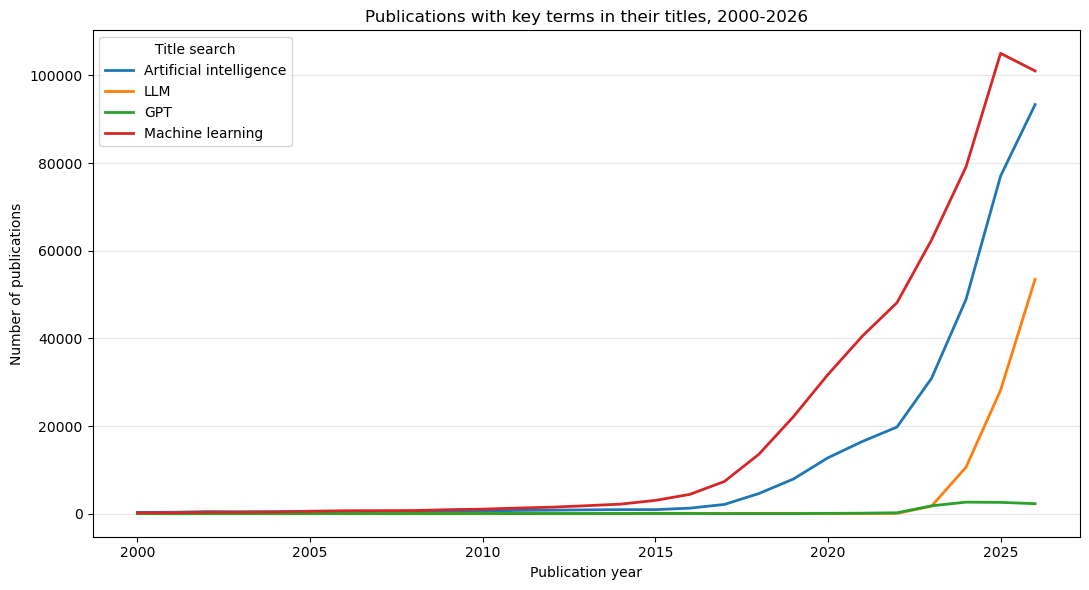

In [12]:
# graph the annual publication counts for all four title searches
yearly_publications.plot(
    x = "Year",
    y = keyword_labels,
    kind = "line",
    figsize = (11, 6),
    linewidth = 2)

plt.title("Publications with key terms in their titles, 2000-2026")
plt.xlabel("Publication year")
plt.ylabel("Number of publications")
plt.legend(title = "Title search")
plt.grid(axis = "y", alpha = 0.3)
plt.tight_layout()
plt.show()

In [13]:
# quality checks for the combined annual table
print("First year used for annual search:", yearly_publications["Year"].min())
print("Last year used for annual search:", yearly_publications["Year"].max())
# print("Number of years:", len(yearly_publications))
# print("Missing values after cleaning:")
# print(yearly_publications.isna().sum())
print("No missing values were present for necessary information")

First year used for annual search: 2000
Last year used for annual search: 2026
No missing values were present for necessary information


### Findings
- Publications with “artificial intelligence” in their titles increased from 12,760 in 2020 to 77,047 in 2025.
- “LLM” displayed the most sudden growth, increasing from 77 publications in 2022 to 1,719 in 2023 and 28,175 in 2025.
- “GPT” increased from 218 publications in 2022 to 1,804 in 2023, reached 2,640 in 2024, and decreased slightly to 2,586 in 2025.
- “Machine learning” was the most common of the four title searches in 2025, with 105,023 publications. Machine learning is consistently the most used term in titles. However, this may be due to the fact that machine learning has been created/relevant long before the introduction of AI and large language models to the public.
- The 2026 totals are incomplete and should not be compared directly with complete publication years. In addition, some uses of “LLM” and “GPT” may represent meanings unrelated to artificial intelligence.

## 5. New insight: Academic fields represented in Artificial Intelligence publications

#### Question: Which academic fields contain the most works with "artificial intelligence" in their titles since 2000?

**Process**

- Use the same title search as the earlier questions and restrict the publication years from 2000 to 2026. 
- Ask OpenAlex to group the matching works by the field connected to each work's primary research topic. Note that OpenAlex assigns one primary topic and academic field to a classified work, so a work is counted in only one field in this analysis. 
- Convert the grouped JSON results into a pandas table, give the columns readable names, and sort the fields from the largest publication count to the smallest.
- Display the ten fields with the most publications. Calculate each field's percentage of the works that have an OpenAlex field classification.
- Some works do not have a primary academic field classification. These works are excluded from the field ranking and reported separately in the quality checks.

In [58]:
# search titles, keep publications from 2000-2026, and group by field
url_question5_api = \
    ('https://api.openalex.org/works?'
     'filter=title.search:"artificial intelligence",publication_year:2000-2026'
     '&group_by=primary_topic.field.id&per-page=200')

# request the grouped info and convert the JSON
field_search = requests.get(url_question5_api).json()

# convert to pandas table
field_table = pd.DataFrame(field_search["group_by"])

# keep the field name and count, then use readable column names
field_table = (field_table [["key_display_name", "count"]]
    .rename(columns = {
        "key_display_name": "Academic field",
        "count": "Number of publications"})
    .sort_values(by = "Number of publications", ascending = False))

# count the works that received a primary-field classification
classified_works = field_table["Number of publications"].sum()

# compare the API total with the classified total
unclassified_works = field_search["meta"]["count"] - classified_works

In [59]:
# select the ten fields with the largest publication counts
top_ten_fields = field_table.head(10).copy()

# calculate each field's percentage of classified publications
top_ten_fields["Share of classified works (%)"] = (
    top_ten_fields["Number of publications"] / classified_works * 100)

# round percentages to one decimal place for a cleaner table
top_ten_fields = top_ten_fields.round(1)

top_ten_fields

,Academic field,Number of publications,Share of classified works (%)
0,Computer Science,74713,23.9
1,Medicine,73018,23.4
2,Social Sciences,40389,12.9
3,Engineering,33581,10.8
4,"Business, Management and Accounting",21259,6.8
5,"Economics, Econometrics and Finance",8864,2.8
6,Decision Sciences,8822,2.8
7,Environmental Science,7531,2.4
8,Psychology,7430,2.4
9,Health Professions,5433,1.7


In [55]:
# quality checks for the field classification
print("Total matching works:", field_search["meta"]["count"])
print("Works with a field classification:", classified_works)
print("Works without a field classification:", unclassified_works)
print("Number of academic fields:", len(field_table))
# print("Missing values in the field table:")
# print(field_table.isna().sum())
print("No missing values in the academic fields table")

Total matching works: 324950
Works with a field classification: 311986
Works without a field classification: 12964
Number of academic fields: 26
No missing values in the academic fields table


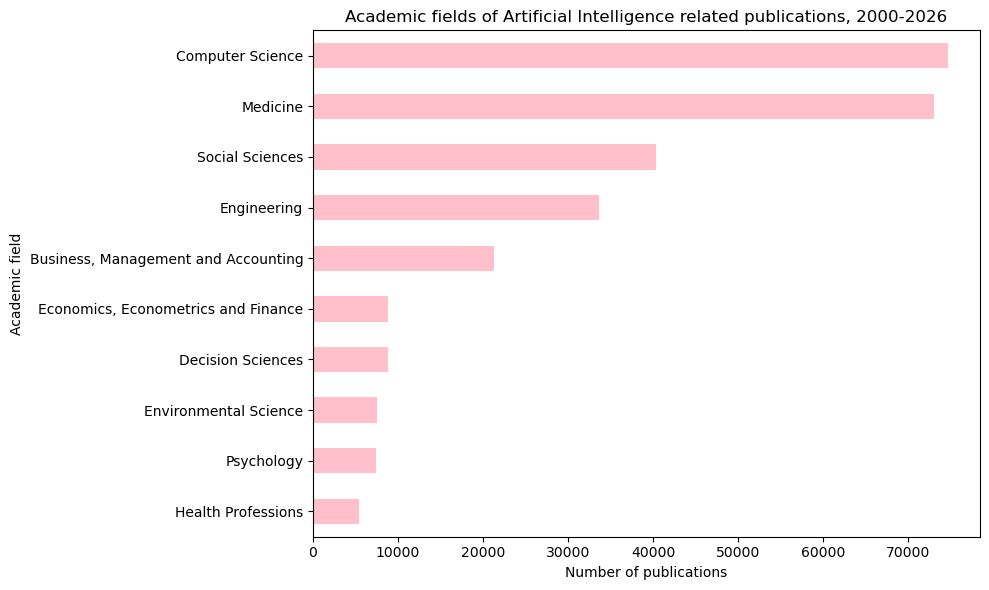

In [54]:
# put smallest field first so the largest bar is at the top
field_plot = top_ten_fields.sort_values(by = "Number of publications", ascending = True)

# create a horizontal bar chart of the ten largest fields
field_plot.plot(
    x = "Academic field",
    y = "Number of publications",
    kind = "barh",
    figsize = (10, 6),
    color = "pink",
    legend = False)

plt.title("Academic fields of Artificial Intelligence related publications, 2000-2026")
plt.xlabel("Number of publications")
plt.ylabel("Academic field")
plt.tight_layout()
plt.show()

## 6. Findings for academic field classification

- Computer Science contains the largest number of classified works with "artificial intelligence" in their titles, with 74,713 publications. This follows the preceding expectations as artifical intelligence is based on computer science. Medicine follows closely with 73,018 publications. Each field represents approximately 24% of the total classified works since 2000.
- Social Sciences ranks third, followed by Engineering, with both categories making up around another 24% of the total works. Business, Management and Accounting ranks fifth.
- The strong representation of Medicine, Social Sciences, and Business shows that artificial intelligence research is not limited to computing and engineering. The phrase now appears across fields concerned with healthcare, human behavior, organizations, and public life.
- OpenAlex does not assign a primary academic field to every matching work. It was made sure that these unclassified works were reported separately, so they are not incorrectly treated as an academic field. However, a work receives only one primary field in this analysis even when its subject is interdisciplinary. For instance, a publication connecting medical diagnosis with computer vision may be counted under Medicine rather than Computer Science. The field totals should be interpreted as each work's main classification rather than every field to which it contributes.